# Credit Card Fraud Detection — XGBoost, cost-based decisions and SHAP

**Data:** ULB / Worldline credit card transactions (Kaggle `mlg-ulb/creditcardfraud`): 284,807 transactions
over 48 hours in September 2013, 492 frauds. `V1`–`V28` are PCA components released instead of the raw
features; only `Time` and `Amount` are in original units.

**What this notebook does, in order**

1. Validates the file and removes 1,081 exact duplicate rows.
2. Splits the data **by time** (first 60% train, next 20% validation, last 20% test), so the model is always tested on later transactions.
3. Compares logistic regression, random forest and XGBoost, scored with PR-AUC and bootstrap confidence intervals.
4. Calibrates XGBoost so its scores can be used as probabilities.
5. Compares five ways of turning scores into alerts, measured in euros saved on the test set.
6. Explains individual decisions with SHAP, including a fraud the model missed.

Every number that is tuned (hyperparameters, calibration, thresholds) is chosen on the validation block.
The test block is used once, at the end.

All logic lives in `src/fraud/`; this notebook calls those functions step by step so the
numbers here match `results/metrics.json` exactly.

## 1. Setup

`sys.path.insert` lets the notebook import the project package from `../src`. `%matplotlib inline`
embeds plots in the saved notebook.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "src") if Path.cwd().name == "notebooks" else str(Path.cwd() / "src"))

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from fraud import config as C, pipeline as PL, evaluate as E, threshold as T, plots as P

pd.set_option("display.float_format", "{:.4f}".format)
print("data file:", C.DATA_PATH)

data file: /home/claude/credit-card-fraud-detection/data/creditcard.csv


## 2. Load and validate

`step_load` reads `data/creditcard.csv` and **raises an error if it is missing** (there is no silent
synthetic fallback). It checks the 31 expected columns, checks for missing values, and drops rows that are
identical in every column.

Why drop duplicates: 1,081 rows appear more than once. With duplicates, the same transaction can land
in both train and test, and the model gets credit for memorising it.

In [2]:
raw, df, info = PL.step_load()
pd.Series(info)

raw_rows                   284807.0000
raw_frauds                    492.0000
duplicates_removed           1081.0000
duplicate_frauds_removed       19.0000
rows                       283726.0000
frauds                        473.0000
fraud_rate_pct                  0.1667
hours_covered                  47.9978
fraud_amount_median             9.8200
legit_amount_median            22.0000
dtype: float64

## 3. Exploratory analysis

**Class balance.** About 1 transaction in 600 is fraud. A model that always says "legit" is 99.83% accurate
and catches nothing, so accuracy is never used here.

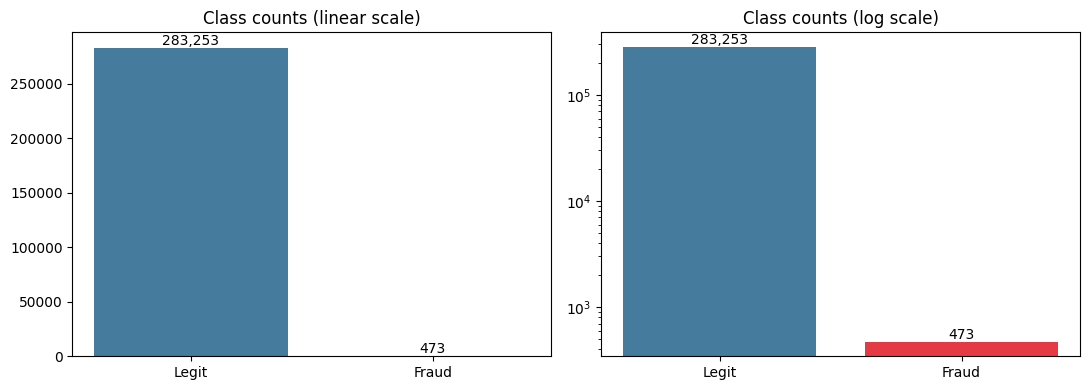

In [3]:
P.class_balance(df, C.FIG_DIR / "01_class_balance.png"); plt.show()

**Amount and time.** Fraud amounts are *smaller* on median (EUR 9.82 vs 22.00) and have spikes at
EUR 0–1 (the tall bar near `log(1+Amount) ≈ 0.7`), which is consistent with card-testing charges. Fraud is
also spread more evenly over the night, when legitimate volume is low.

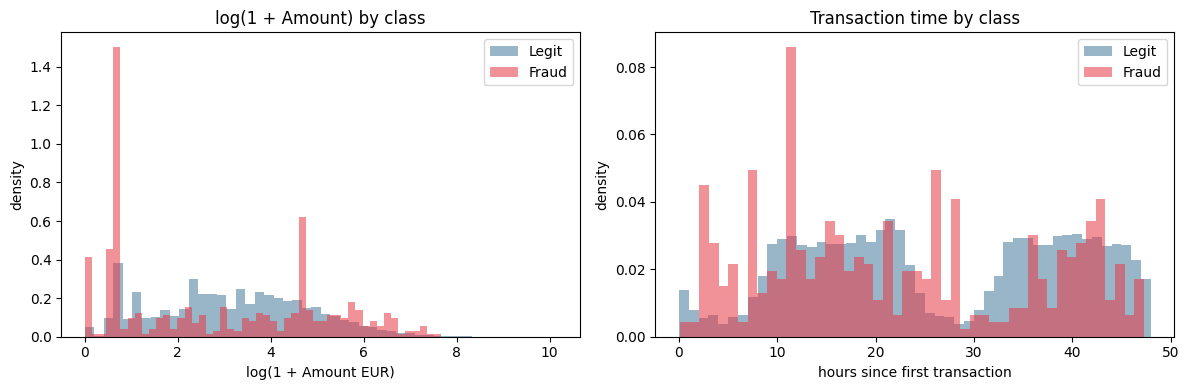

In [4]:
P.amount_and_time(df, C.FIG_DIR / "02_amount_time.png"); plt.show()

## 4. Chronological split

`chronological_split` sorts by `Time` and cuts 60 / 20 / 20. A random split would let the model train on
transactions from minutes *after* a test transaction, which does not match how a deployed model is used
and can inflate scores (measured in section 7).

Note the validation block has only **57 frauds** and test has **74**. Every metric below carries that
uncertainty, which is why bootstrap intervals are reported.

,split,rows,frauds,fraud_rate_pct,time_start_h,time_end_h
0,train,170235,342,0.2009,0.0000,33.4400
1,validation,56745,57,0.1004,33.4400,40.3400
2,test,56746,74,0.1304,40.3400,48.0000


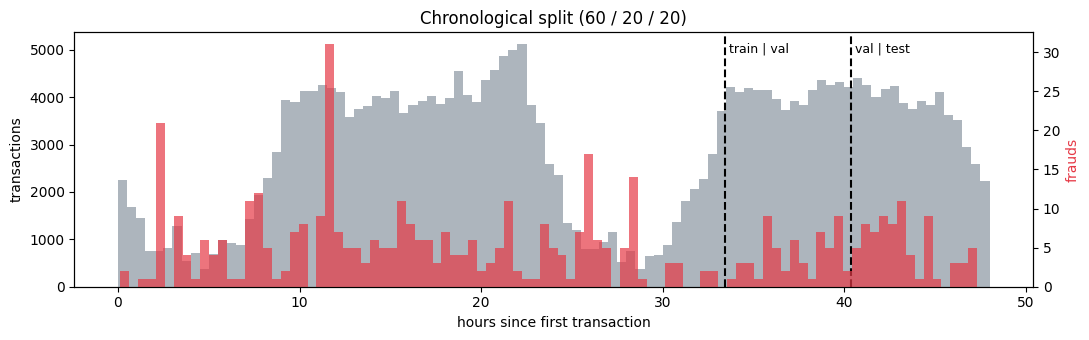

In [5]:
tr, va, te, split_table = PL.step_split(df)
display(split_table)
cuts = [tr["Time"].max() / 3600, va["Time"].max() / 3600]
P.split_timeline(df.sort_values("Time"), cuts, C.FIG_DIR / "03_split_timeline.png"); plt.show()

## 5. Features

`build_features` is stateless (no fitted statistics), so it cannot leak information from test into train.

| feature | why |
|---|---|
| `V1`–`V28` | used as given; already centred by PCA |
| `log_amount = log(1 + Amount)` | Amount is very right-skewed; `log1p` compresses it and handles EUR 0 |
| `hour_sin`, `hour_cos` | position in the 24-hour cycle, on a circle so 23:59 is next to 00:00 |
| raw `Time` | **dropped**: it only encodes "day 1 vs day 2", which would not generalise to future data |

In [6]:
(Xtr, ytr), (Xva, yva), (Xte, yte) = PL.step_features(tr, va, te)
print("train", Xtr.shape, "val", Xva.shape, "test", Xte.shape)
Xtr.head(3)

train (170235, 31) val (56745, 31) test (56746, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,log_amount,hour_sin,hour_cos
0,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,...,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,5.0148,0.0000,1.0000
1,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,...,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,1.3056,0.0000,1.0000
2,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,...,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,5.9393,0.0001,1.0000


## 6. XGBoost tuning on validation

**`scale_pos_weight`** = legit / fraud in the training block (~497). XGBoost multiplies each fraud row's
gradient and Hessian by this, so the loss treats one fraud like ~497 legit rows.

A small grid (`max_depth` ∈ {3, 5, 7} × `min_child_weight` ∈ {1, 5}) is scored on **validation PR-AUC**.
`max_depth` limits how many feature interactions one tree can use; `min_child_weight` stops splits that
isolate only a handful of (weighted) rows, which matters with so few frauds.

In [7]:
xgb_model, grid, best, spw = PL.step_tune_xgb(Xtr, ytr, Xva, yva)
print(f"scale_pos_weight = {spw:.1f}; best = {best}")
grid

scale_pos_weight = 496.8; best = {'max_depth': 5, 'min_child_weight': 5}


,max_depth,min_child_weight,val_pr_auc
0,5,5,0.7872
1,7,1,0.7866
2,5,1,0.7855
3,7,5,0.7786
4,3,5,0.7745
5,3,1,0.7672


## 7. Model comparison

All three models are fit on the training block only:

- **Logistic regression** with `class_weight="balanced"` and a `StandardScaler` inside a `Pipeline`
  (so the scaler only ever sees training rows).
- **Random forest**, 300 trees, `class_weight="balanced_subsample"`.
- **XGBoost** with the parameters chosen above.

**PR-AUC** (average precision) summarises precision across all recall levels. Its random baseline is the
fraud rate (0.0013 on test), not 0.5. **ROC-AUC** is shown for contrast: logistic regression has the
*highest* ROC-AUC but the *lowest* PR-AUC, because ROC's false-positive rate is divided by ~56,000
legitimate transactions and hides thousands of false alarms.

`precision@100` = share of real frauds among the 100 highest-scored test transactions (a fixed analyst queue).

,model,val_pr_auc,test_pr_auc,test_roc_auc,test_precision_at_100,recall_at_0.5,precision_at_0.5,tp_at_0.5,fp_at_0.5
0,Logistic regression,0.7532,0.7446,0.9812,0.5900,0.9054,0.0228,67,2872
1,Random forest,0.7650,0.8094,0.9648,0.5900,0.7162,0.8689,53,8
2,XGBoost,0.7872,0.7980,0.9703,0.6000,0.7568,0.7568,56,18


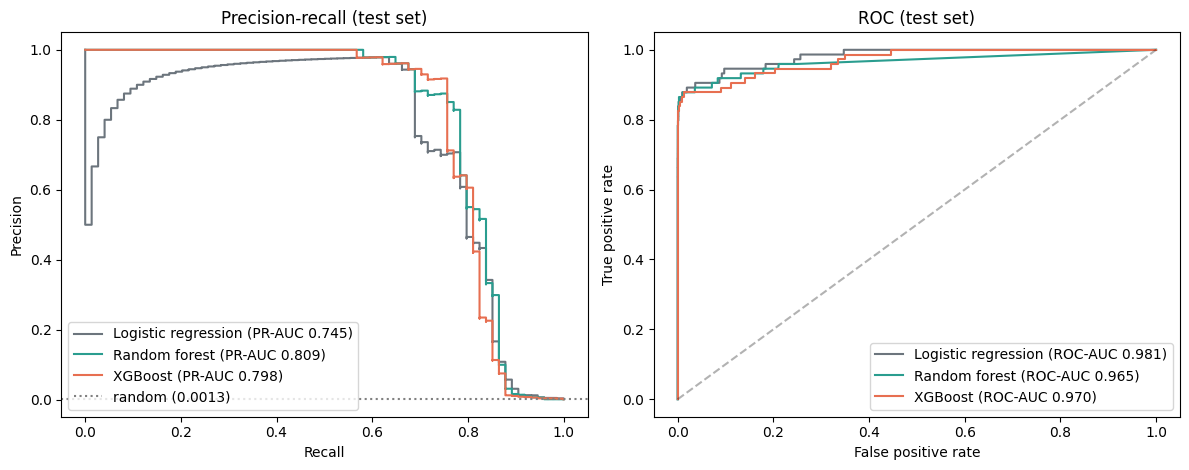

In [8]:
fitted, val_p, test_p, comparison = PL.step_models(Xtr, ytr, Xva, yva, Xte, yte, xgb_model)
display(comparison)
P.pr_roc(yte, test_p, C.FIG_DIR / "04_pr_roc.png"); plt.show()

**Is the difference real?** `bootstrap_pr_auc` resamples the test rows 1,000 times (same resample for every
model, i.e. paired) and reports 95% percentile intervals.

Random forest scores slightly higher than XGBoost on test, but XGBoost was chosen **on validation**, where it
led (0.787 vs 0.765). The paired difference interval includes zero, so the two are statistically tied on
74 test frauds. Picking the model by its test score would be test-set leakage.

,model,mean,ci_low,ci_high
0,Logistic regression,0.7525,0.6384,0.8518
1,Random forest,0.8095,0.7317,0.8886
2,XGBoost,0.7979,0.7150,0.8771


XGBoost - Logistic regression: +0.045  95% CI [-0.014, +0.130]
XGBoost - Random forest: -0.012  95% CI [-0.040, +0.014]


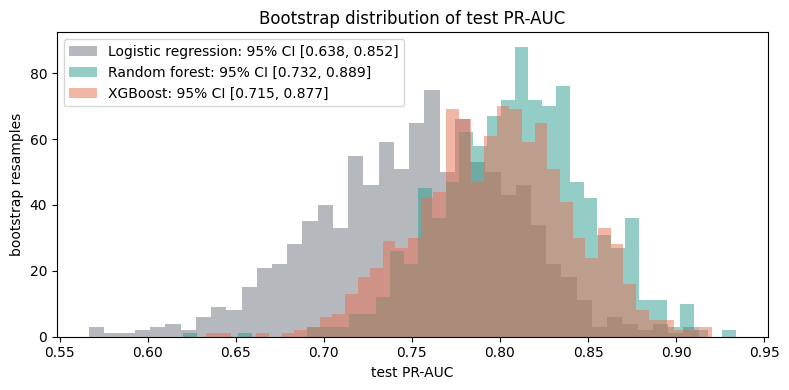

In [9]:
boot = E.bootstrap_pr_auc(yte, test_p, C.N_BOOTSTRAP, C.SEED)
rows = []
for k, b in boot.items():
    rows.append({"model": k, "mean": b["mean"], "ci_low": b["ci_low"], "ci_high": b["ci_high"]})
display(pd.DataFrame(rows))
for k in ["Logistic regression", "Random forest"]:
    d = boot["XGBoost"]["samples"] - boot[k]["samples"]
    print(f"XGBoost - {k}: {d.mean():+.3f}  95% CI [{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]")
P.bootstrap_hist(boot, C.FIG_DIR / "05_bootstrap_pr_auc.png"); plt.show()

**How optimistic is a random split?** Same features and XGBoost settings, stratified random 80/20 split.
On this dataset the gap is small (about 2 PR-AUC points, well inside the bootstrap interval). The
chronological split is kept because it matches deployment, not because the gap is large.

In [10]:
rand_pr, rand_frauds = PL.step_random_split_gap(df, best)
chrono_pr = comparison.set_index("model").loc["XGBoost", "test_pr_auc"]
print(f"random split PR-AUC {rand_pr:.3f} vs chronological {chrono_pr:.3f} -> {100*(rand_pr-chrono_pr):.1f} points optimism")

random split PR-AUC 0.817 vs chronological 0.798 -> 1.9 points optimism


## 8. Calibration

Because of `scale_pos_weight`, raw XGBoost scores are inflated: a score of 0.5 is not a 50% chance of fraud.
**Platt scaling** fits a one-variable logistic regression on the model's log-odds, using the validation
block. It is monotonic, so PR-AUC and ROC-AUC do not change; only the scale does.

**Brier score** = mean squared error between predicted probability and the 0/1 label (lower is better).

brier_raw              0.0005
brier_calibrated       0.0004
pr_auc_raw             0.7980
pr_auc_calibrated      0.7980
mean_raw_score_test    0.0018
mean_calibrated_test   0.0012
test_fraud_rate        0.0013
dtype: float64

raw score 0.5 corresponds to calibrated probability 0.082


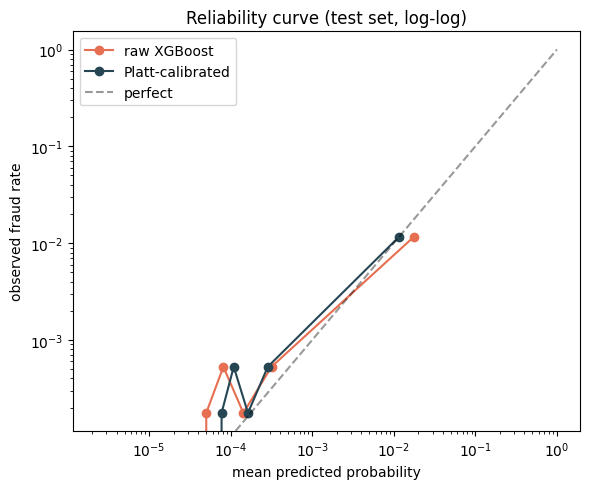

In [11]:
cal, p_val, p_test, cal_info = PL.step_calibrate(val_p["XGBoost"], yva, test_p["XGBoost"], yte)
display(pd.Series(cal_info))
print("raw score 0.5 corresponds to calibrated probability", round(float(cal.transform([0.5])[0]), 3))
P.calibration(yte, test_p["XGBoost"], p_test, C.FIG_DIR / "06_calibration.png"); plt.show()

## 9. From scores to decisions

**Cost model (assumption, EUR):** every alert costs **5** in analyst review time; every missed fraud costs its
full `Amount`. "Saving" = share of the no-model loss (all fraud lost) that a policy avoids, after paying for
reviews. "Value recall" = share of fraud *euros* caught.

Five policies, all fixed before looking at test:

| policy | rule |
|---|---|
| Default 0.5 | raw score ≥ 0.5 (what `model.predict()` does) |
| 90% recall target | lowest calibrated threshold that reaches 90% recall on validation |
| Cost-optimal threshold | single threshold minimising validation cost |
| Expected-cost rule | flag if **P(fraud) × Amount ≥ 5** |
| Expected-cost + guardrail | expected-cost rule, **or** P(fraud) ≥ 0.5 |

The expected-cost rule is the decision-theory answer: reviewing is worth it when the expected loss avoided
exceeds the review cost. It needs no tuned threshold, only calibrated probabilities. Its weakness is that it
never flags tiny transactions, and small card-testing charges often come before larger fraud. The guardrail
is a fixed business rule that covers them, at the price of more alerts.

In [12]:
thresholds, test_rows, val_rows, val_sweep, sens = PL.step_policies(
    p_val, yva, va["Amount"].values, test_p["XGBoost"], p_test, yte, te["Amount"].values, cal)
print({k: round(v, 5) for k, v in thresholds.items()})
cols = ["alerts", "tp", "fp", "fn", "recall", "precision", "value_recall", "review_cost_eur",
        "missed_fraud_eur", "total_cost_eur", "saving_vs_no_model_pct"]
print("VALIDATION"); display(pd.DataFrame(val_rows).T[cols])
print("TEST"); display(pd.DataFrame(test_rows).T[cols])

{'cost_optimal_global': 0.67387, 'recall90_global': 0.00046, 'raw_0.5_in_calibrated_units': 0.0817}
VALIDATION


,alerts,tp,fp,fn,recall,precision,value_recall,review_cost_eur,missed_fraud_eur,total_cost_eur,saving_vs_no_model_pct
Cost-optimal threshold,42.0000,41.0000,1.0000,16.0000,0.7193,0.9762,0.6341,210.0000,4475.8600,4685.8600,61.6889
Expected-cost rule,76.0000,27.0000,49.0000,30.0000,0.4737,0.3553,0.6328,380.0000,4490.7400,4870.7400,60.1774
Expected-cost + guardrail,94.0000,43.0000,51.0000,14.0000,0.7544,0.4574,0.6341,470.0000,4474.8600,4944.8600,59.5714


TEST


,alerts,tp,fp,fn,recall,precision,value_recall,review_cost_eur,missed_fraud_eur,total_cost_eur,saving_vs_no_model_pct
Default 0.5,74.0000,56.0000,18.0000,18.0000,0.7568,0.7568,0.6586,370.0000,2638.2700,3008.2700,61.0714
90% recall target,4958.0000,65.0000,4893.0000,9.0000,0.8784,0.0131,0.7780,24790.0000,1715.5900,26505.5900,-242.9959
Cost-optimal threshold,55.0000,52.0000,3.0000,22.0000,0.7027,0.9455,0.5243,275.0000,3676.2000,3951.2000,48.8695
Expected-cost rule,78.0000,25.0000,53.0000,49.0000,0.3378,0.3205,0.7661,390.0000,1807.4000,2197.4000,71.5645
Expected-cost + guardrail,115.0000,57.0000,58.0000,17.0000,0.7703,0.4957,0.7713,575.0000,1767.4700,2342.4700,69.6872


**Reading the result**

- The **90% recall target** flags ~5,000 transactions to find 65 frauds; review cost exceeds the fraud it
  prevents, so it is worse than having no model at all.
- The **single cost-optimal threshold** looked best on validation but generalised worst of the positive
  policies. With only 57 validation frauds, the cost curve is flat and noisy near its minimum, so the exact
  threshold it picks is mostly chance.
- The **expected-cost rule** is the most robust: it saves the most money while catching only a third of fraud
  *cases*, because it concentrates reviews on high-value transactions (77% of fraud *euros* caught).
- **With the guardrail**, case recall rises to 77% for about 2 points less saving.

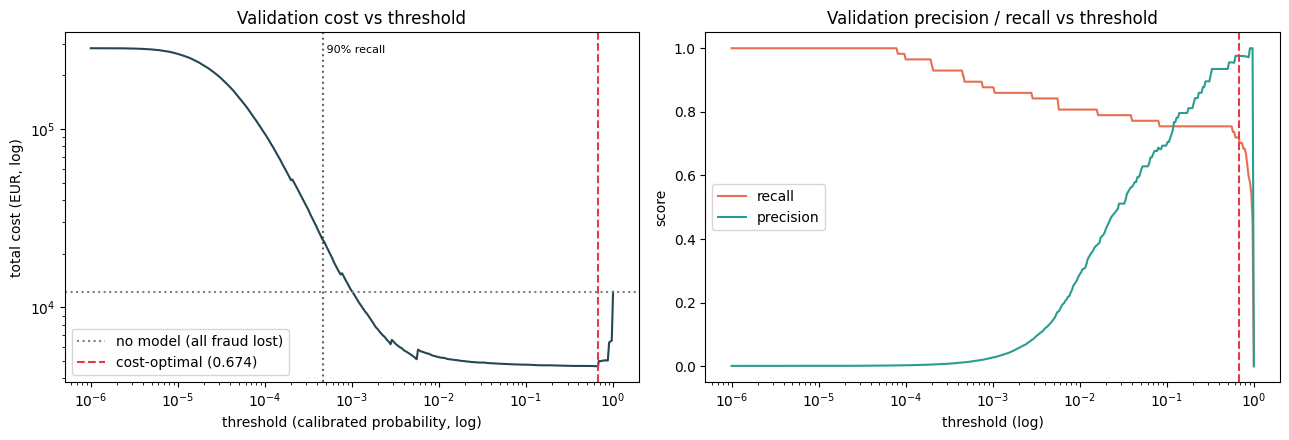

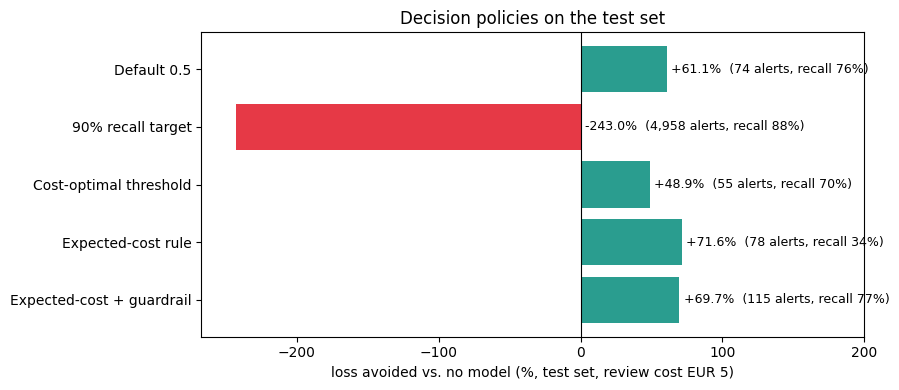

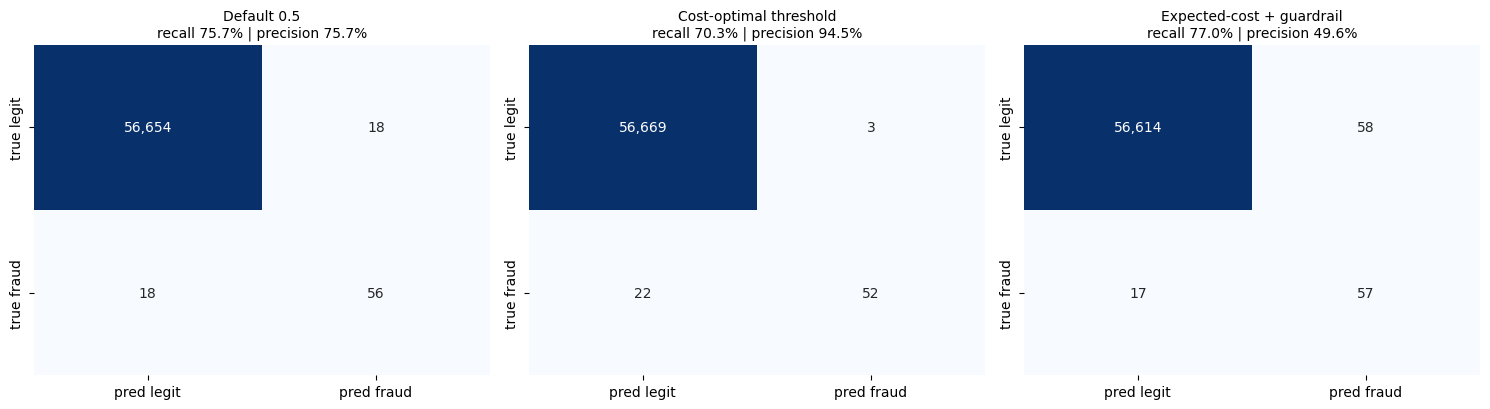

In [13]:
P.cost_curve(val_sweep, thresholds["cost_optimal_global"], {"90% recall": thresholds["recall90_global"]},
             C.FIG_DIR / "07_cost_curve.png"); plt.show()
P.policy_savings(test_rows, C.FIG_DIR / "08_policy_savings.png"); plt.show()
P.confusion_pair({k: test_rows[k] for k in ("Default 0.5", "Cost-optimal threshold", "Expected-cost + guardrail")},
                 C.FIG_DIR / "09_confusion_matrices.png"); plt.show()

**Sensitivity to the review-cost assumption.** The EUR 5 figure is an assumption, so every policy is re-run
for EUR 1–20. The single-threshold policy jumps around (its chosen threshold moves from 0.003 to 0.674),
while the expected-cost rule degrades smoothly.

In [14]:
sens

,review_cost_eur,global_threshold,global_saving_pct,expected_cost_saving_pct,expected_cost_alerts,guardrail_saving_pct,guardrail_alerts,guardrail_recall
0,1.0000,0.0028,69.9944,72.6946,327,72.5342,355,0.7703
1,2.0000,0.0056,70.2274,72.4504,170,71.8742,203,0.7703
2,5.0000,0.6739,48.8695,71.5645,78,69.6872,115,0.7703
3,10.0000,0.6739,45.3108,62.5019,44,58.1792,83,0.7568
4,20.0000,0.6739,38.1935,57.2240,28,47.7342,68,0.7297


## 10. Explainability with SHAP

**SHAP** (SHapley Additive exPlanations) splits one prediction into per-feature contributions that add up
exactly: `base value + Σ SHAP values = model output`. **TreeExplainer** computes these exactly for tree
ensembles in polynomial time.

Units are **log-odds of the raw (uncalibrated) XGBoost model**. A contribution of +1 multiplies the odds of
fraud by e ≈ 2.7. The base value is high (≈ 2.5) because `scale_pos_weight` shifts the raw output.

Global importance = mean |SHAP| over 2,000 random test rows.

,mean |SHAP|
V4,1.8468
V14,1.7389
V12,1.2213
V11,0.8021
V10,0.7398
V8,0.6024
V1,0.5944
log_amount,0.4339
V24,0.4256
V17,0.4109


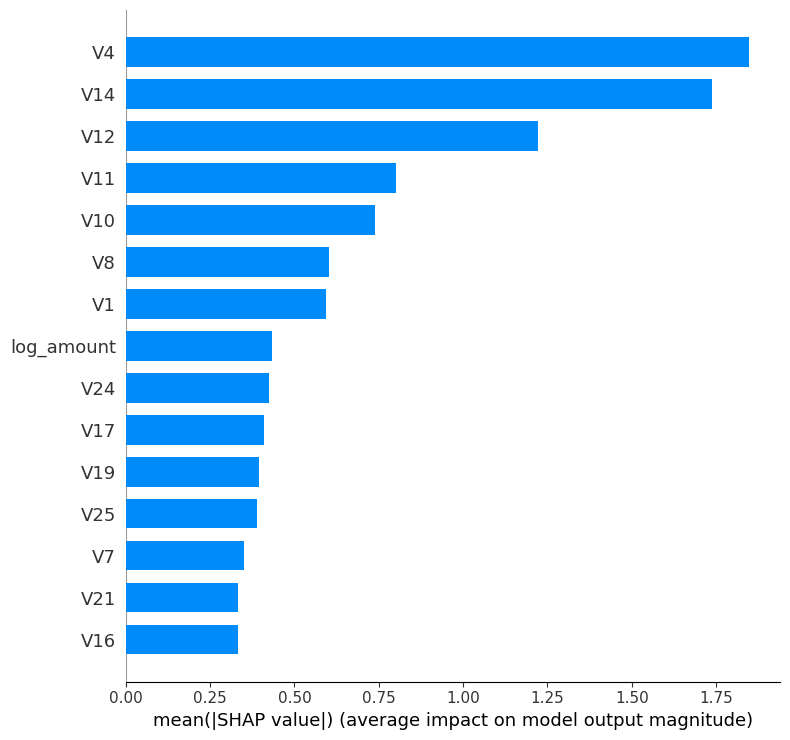

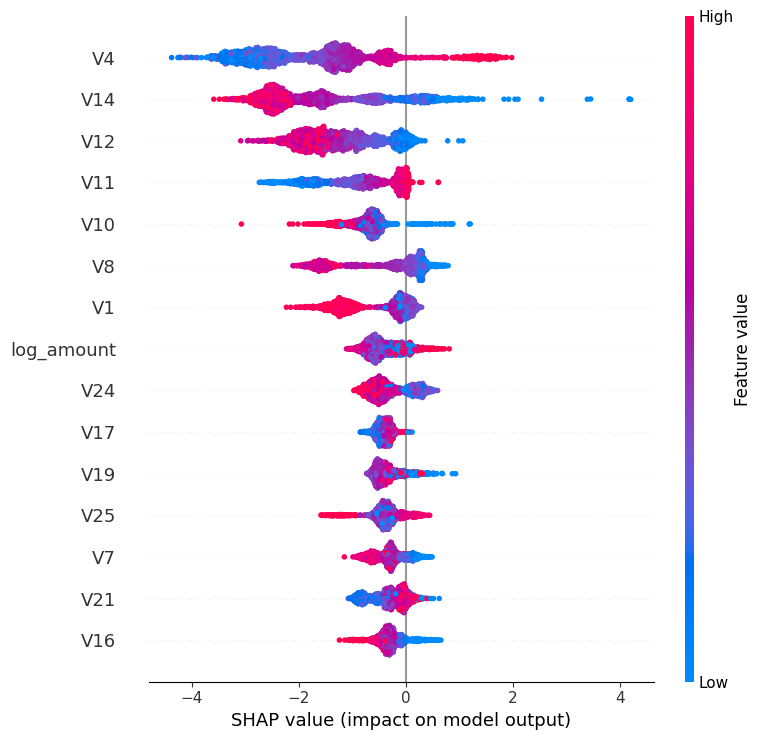

In [15]:
sh = PL.step_shap(xgb_model, Xte, yte, p_test, T.guarded_flags(p_test, te["Amount"].values, C.REVIEW_COST))
display(sh["importance"].head(10).to_frame("mean |SHAP|"))
P.shap_bar(sh["shap_values"], sh["sample"], C.FIG_DIR / "10_shap_importance.png"); plt.show()
P.shap_beeswarm(sh["shap_values"], sh["sample"], C.FIG_DIR / "11_shap_beeswarm.png"); plt.show()

**Beeswarm reading:** each dot is a transaction; colour is the feature value. For `V14`, `V12` and `V10`,
low (blue) values push toward fraud; for `V4` and `V11`, high (red) values do. `log_amount` ranks 8th, and
the hour features are not in the top 15, so the model is not leaning on time of day.

**Per-transaction explanations.** The first waterfall is the highest-scored fraud in test. The second is the
lowest-scored fraud: a transaction that looked normal on every strong component, which no threshold could
catch without flagging thousands of legitimate transactions.

Highest-scored fraud in the test set {'score_calibrated': 0.9957983040920488, 'raw_log_odds': 11.084272384643555, 'base_log_odds': 2.478799343109131}


,feature,value,shap
0,V14,-4.2880,3.9660
1,V10,-4.5335,1.3050
2,V4,3.0444,1.1294


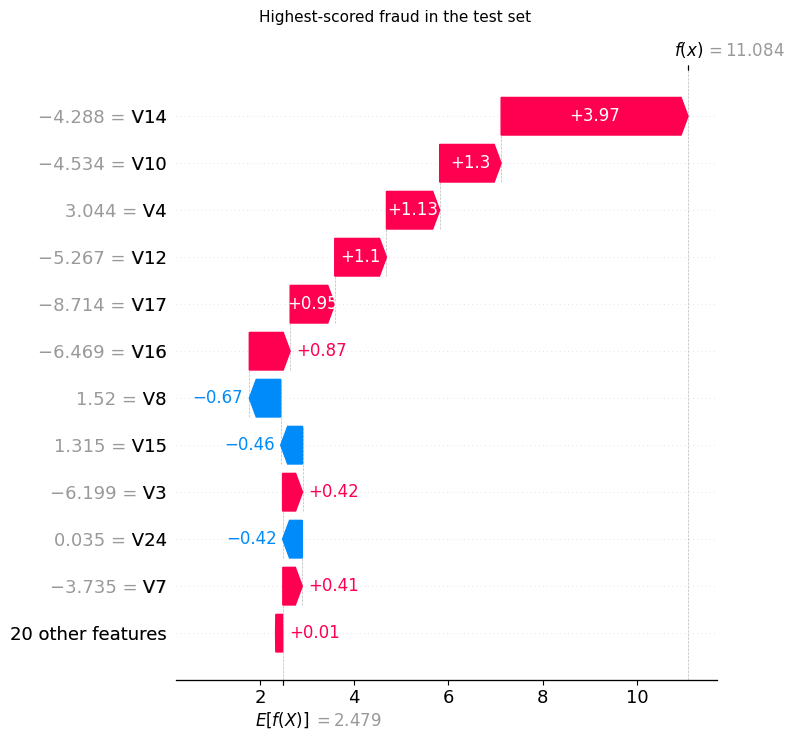

A fraud the model missed {'score_calibrated': 7.789109774918287e-05, 'raw_log_odds': -9.89274787902832, 'base_log_odds': 2.478799343109131}


,feature,value,shap
0,V11,-1.4751,-2.2570
1,V14,0.9843,-2.1929
2,V8,0.7217,-1.7778


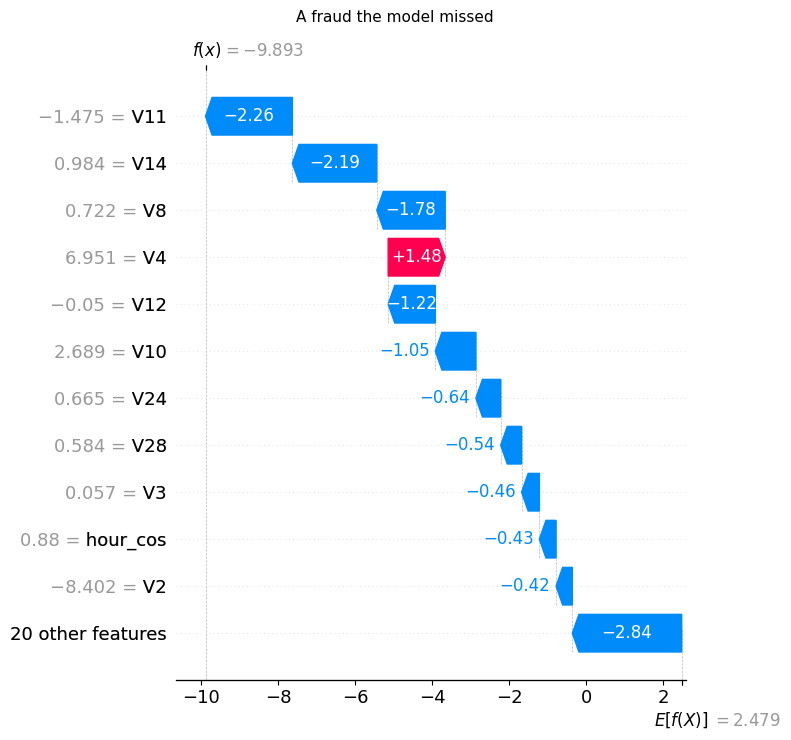

In [16]:
for key, title, fname in [("caught", "Highest-scored fraud in the test set", "12_shap_waterfall_caught.png"),
                          ("missed", "A fraud the model missed", "13_shap_waterfall_missed.png")]:
    exp, meta = sh[key]
    print(title, {k: v for k, v in meta.items() if k != "top_features"})
    display(pd.DataFrame(meta["top_features"]))
    P.shap_waterfall(exp, title, C.FIG_DIR / fname); plt.show()

## 11. Limitations

1. **Small positive counts.** 57 validation and 74 test frauds. The test PR-AUC interval is roughly ±0.08,
   and single-threshold selection is unstable (section 9).
2. **Two days of data.** The chronological split is a 48-hour proxy for real drift; production fraud
   patterns change over weeks and months.
3. **The cost model is simplified.** Real costs include chargeback fees, customer churn from false declines
   and analyst capacity limits. The review cost is an assumption, which is why sensitivity is reported.
4. **Anonymised features.** `V14` can be ranked but not interpreted in business terms, so SHAP explanations
   are useful for auditing the model, not for telling a customer *why* in plain language.
5. **Validation is used three times** (hyperparameters, calibration, thresholds). A larger dataset would use
   separate blocks for each.
6. **No card or customer ID**, so velocity features (transactions per card per hour), the strongest
   signals in real systems, cannot be built.